# 📊 Unemployment Analysis in India

## 1️⃣ Import Libraries

In [1]:
import sys
!{sys.executable} -m pip install plotly


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\manya\Documents\AIMLProjects\ml_env\Scripts\python.exe -m pip install --upgrade pip


In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import joblib
import os

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2️⃣ Download Dataset from Kaggle

In [3]:
# Download latest version
path = kagglehub.dataset_download("gokulrajkmv/unemployment-in-india")
print("Path to dataset files:", path)

# List all files in the downloaded folder
files = os.listdir(path)
print("\n📁 Files available:", files)

100%|██████████████████████████████████████████████████████████████████████████████| 16.0k/16.0k [00:00<00:00, 317kB/s]

Extracting files...
Path to dataset files: C:\Users\manya\.cache\kagglehub\datasets\gokulrajkmv\unemployment-in-india\versions\5

📁 Files available: ['Unemployment in India.csv', 'Unemployment_Rate_upto_11_2020.csv']


In [4]:
# Load the CSV file
csv_file = [f for f in files if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print(f"✅ Dataset loaded: {csv_file}")
print(f"\n📐 Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head(10)

✅ Dataset loaded: Unemployment in India.csv

📐 Shape: 768 rows × 7 columns


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
5,Andhra Pradesh,31-10-2019,Monthly,3.52,12017412.0,43.01,Rural
6,Andhra Pradesh,30-11-2019,Monthly,4.12,11397681.0,41.00,Rural
7,Andhra Pradesh,31-12-2019,Monthly,4.38,12528395.0,45.14,Rural
8,Andhra Pradesh,31-01-2020,Monthly,4.84,12016676.0,43.46,Rural
9,Andhra Pradesh,29-02-2020,Monthly,5.91,11723617.0,42.83,Rural


## 3️⃣ Data Cleaning & Preprocessing

In [5]:
# Clean column names — strip whitespace
df.columns = df.columns.str.strip()
print("📋 Columns:", df.columns.tolist())

# Rename for convenience
df.rename(columns={
    'Region': 'State',
    'Date': 'Date',
    'Frequency': 'Frequency',
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate',
    'Region.1': 'Region_Type',
    'longitude': 'Longitude',
    'latitude': 'Latitude'
}, inplace=True)

print("\n✅ Renamed Columns:", df.columns.tolist())

📋 Columns: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']

✅ Renamed Columns: ['State', 'Date', 'Frequency', 'Unemployment_Rate', 'Employed', 'Labour_Participation_Rate', 'Area']


In [6]:
# Check data types
print("📊 Data Types:")
print(df.dtypes)

# Parse Date column properly
df['Date'] = pd.to_datetime(df['Date'].str.strip(), dayfirst=True)

# Extract useful time features — engineers call this 'feature engineering'
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Month_Name'] = df['Date'].dt.strftime('%B')
df['Quarter'] = df['Date'].dt.quarter

print("\n✅ Date parsed. Sample:")
df[['Date','Month','Year','Quarter']].head()

📊 Data Types:
State                         object
Date                          object
Frequency                     object
Unemployment_Rate            float64
Employed                     float64
Labour_Participation_Rate    float64
Area                          object
dtype: object

✅ Date parsed. Sample:


,Date,Month,Year,Quarter
0,2019-05-31,5.0,2019.0,2.0
1,2019-06-30,6.0,2019.0,2.0
2,2019-07-31,7.0,2019.0,3.0
3,2019-08-31,8.0,2019.0,3.0
4,2019-09-30,9.0,2019.0,3.0


In [7]:
# Check for missing values
print("🔍 Missing Values:")
print(df.isnull().sum())

# Drop rows with missing unemployment rate (our target)
df.dropna(subset=['Unemployment_Rate'], inplace=True)

# Fill remaining numeric nulls with median (robust to outliers)
for col in ['Employed', 'Labour_Participation_Rate']:
    if col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)

print(f"\n✅ After cleaning: {df.shape[0]} rows remain")

🔍 Missing Values:
State                        28
Date                         28
Frequency                    28
Unemployment_Rate            28
Employed                     28
Labour_Participation_Rate    28
Area                         28
Month                        28
Year                         28
Month_Name                   28
Quarter                      28
dtype: int64

✅ After cleaning: 740 rows remain


In [8]:
# Basic statistics — always do this to understand your data
print("📈 Statistical Summary:")
df[['Unemployment_Rate', 'Employed', 'Labour_Participation_Rate']].describe().round(2)

📈 Statistical Summary:


,Unemployment_Rate,Employed,Labour_Participation_Rate
count,740.00,740.00,740.00
mean,11.79,7204460.03,42.63
std,10.72,8087988.43,8.11
min,0.00,49420.00,13.33
25%,4.66,1190404.50,38.06
50%,8.35,4744178.50,41.16
75%,15.89,11275489.50,45.50
max,76.74,45777509.00,72.57


## 4️⃣ Exploratory Data Analysis (EDA)

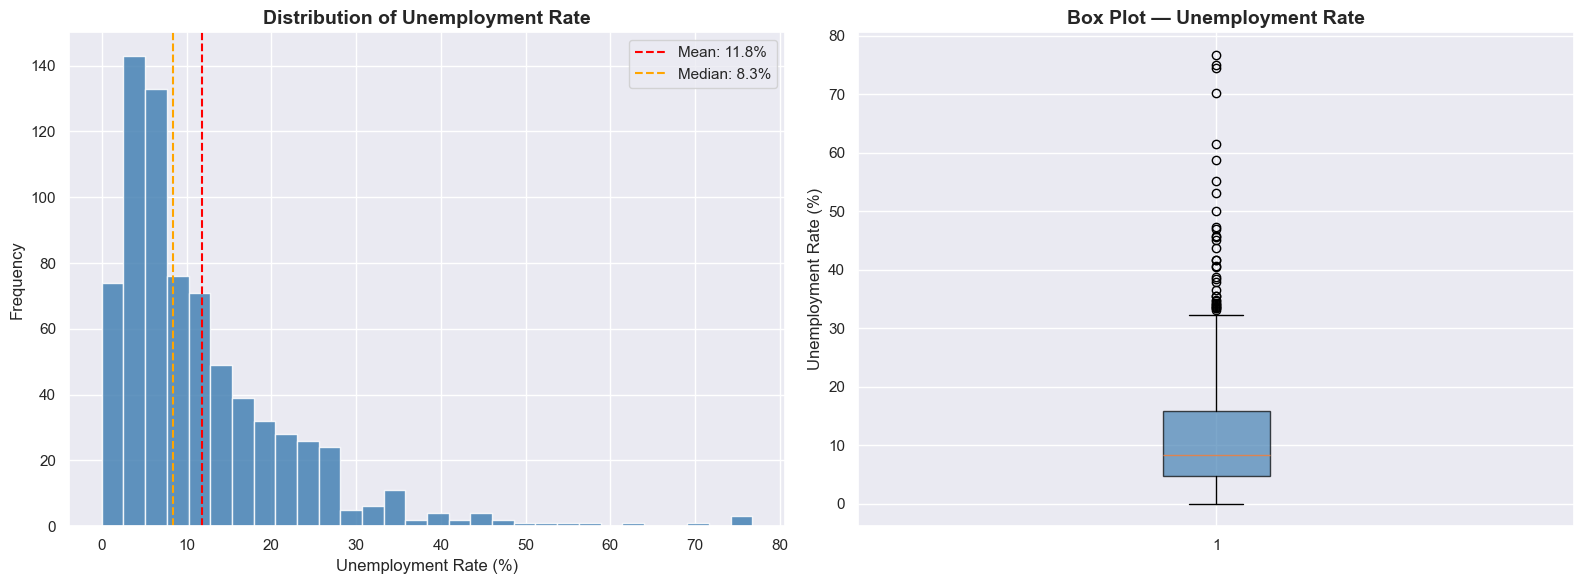

💡 Insight: Most states have 5–20% unemployment, but spikes exist (COVID-19 lockdowns)


In [9]:
# ── Plot 1: Distribution of Unemployment Rate ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(df['Unemployment_Rate'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Unemployment_Rate'].mean(), color='red', linestyle='--', label=f"Mean: {df['Unemployment_Rate'].mean():.1f}%")
axes[0].axvline(df['Unemployment_Rate'].median(), color='orange', linestyle='--', label=f"Median: {df['Unemployment_Rate'].median():.1f}%")
axes[0].set_title('Distribution of Unemployment Rate', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Unemployment Rate (%)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
axes[1].boxplot(df['Unemployment_Rate'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Box Plot — Unemployment Rate', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Unemployment Rate (%)')

plt.tight_layout()
plt.savefig('plot_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Insight: Most states have 5–20% unemployment, but spikes exist (COVID-19 lockdowns)")

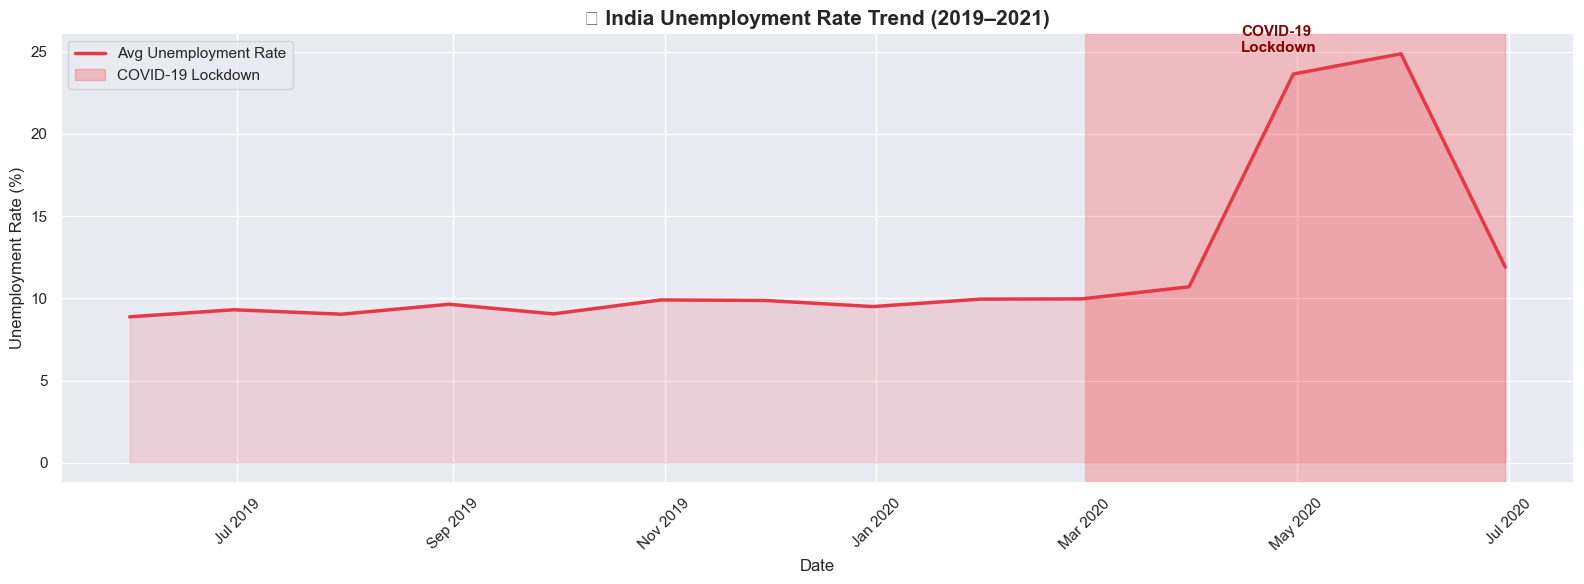

💡 Insight: Massive spike in April-May 2020 due to COVID-19 national lockdown


In [10]:
# ── Plot 2: National Unemployment Trend Over Time ──
monthly_avg = df.groupby('Date')['Unemployment_Rate'].mean().reset_index()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(monthly_avg['Date'], monthly_avg['Unemployment_Rate'], 
        color='#E63946', linewidth=2.5, label='Avg Unemployment Rate')
ax.fill_between(monthly_avg['Date'], monthly_avg['Unemployment_Rate'], 
                alpha=0.15, color='#E63946')

# Mark COVID period
covid_start = pd.Timestamp('2020-03-01')
covid_end = pd.Timestamp('2020-06-30')
ax.axvspan(covid_start, covid_end, alpha=0.2, color='red', label='COVID-19 Lockdown')
ax.annotate('COVID-19\nLockdown', xy=(pd.Timestamp('2020-04-15'), 25),
            fontsize=11, color='darkred', fontweight='bold')

ax.set_title('📈 India Unemployment Rate Trend (2019–2021)', fontsize=15, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Unemployment Rate (%)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Insight: Massive spike in April-May 2020 due to COVID-19 national lockdown")

📊 COVID Period Statistics:
                 mean  median    max
COVID_Period                        
COVID Lockdown  17.77   14.52  76.74
Pre-COVID        9.51    7.12  34.69


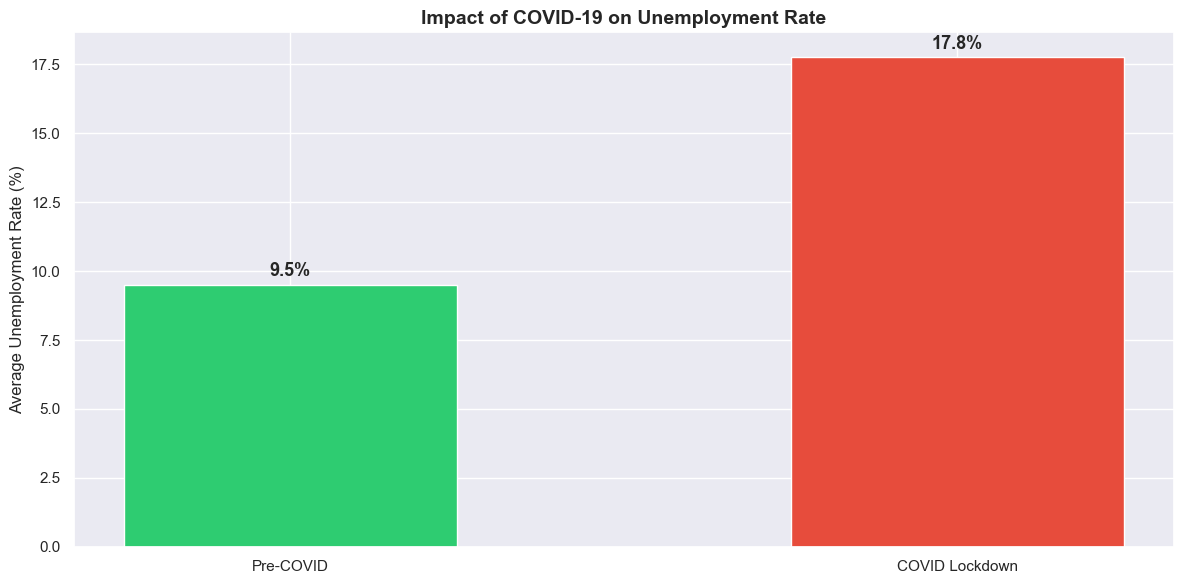

In [11]:
# ── Plot 3: COVID-19 Impact — Pre vs During vs Post ──
df['COVID_Period'] = 'Pre-COVID'
df.loc[(df['Date'] >= '2020-03-01') & (df['Date'] <= '2020-06-30'), 'COVID_Period'] = 'COVID Lockdown'
df.loc[df['Date'] > '2020-06-30', 'COVID_Period'] = 'Post-COVID'

covid_summary = df.groupby('COVID_Period')['Unemployment_Rate'].agg(['mean','median','max']).round(2)
print("📊 COVID Period Statistics:")
print(covid_summary)

fig, ax = plt.subplots(figsize=(12, 6))
order = ['Pre-COVID', 'COVID Lockdown', 'Post-COVID']
colors = ['#2ECC71', '#E74C3C', '#3498DB']
covid_means = [df[df['COVID_Period']==p]['Unemployment_Rate'].mean() for p in order]
bars = ax.bar(order, covid_means, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, covid_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=13)
ax.set_title('Impact of COVID-19 on Unemployment Rate', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Unemployment Rate (%)')
plt.tight_layout()
plt.savefig('plot_covid_impact.png', dpi=150, bbox_inches='tight')
plt.show()

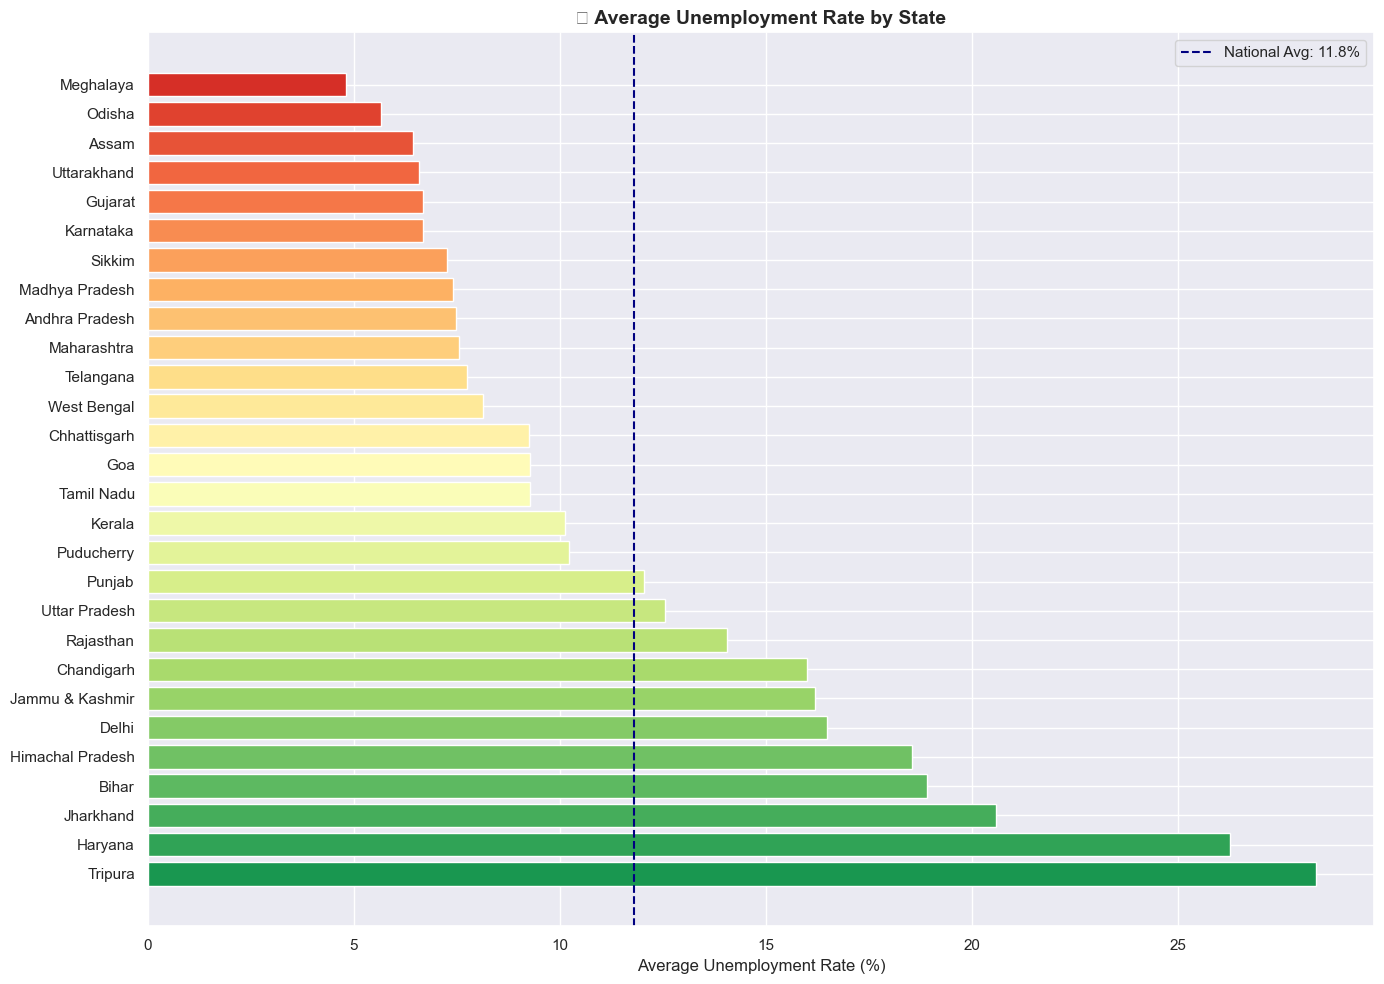

💡 Insight: Urban states like Tripura, HR show higher unemployment vs agricultural states


In [12]:
# ── Plot 4: State-wise Unemployment Heatmap ──
state_avg = df.groupby('State')['Unemployment_Rate'].mean().sort_values(ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(14, 10))
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(state_avg)))
bars = ax.barh(state_avg['State'], state_avg['Unemployment_Rate'], color=colors)
ax.set_title('📍 Average Unemployment Rate by State', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Unemployment Rate (%)')
ax.axvline(state_avg['Unemployment_Rate'].mean(), color='navy', 
           linestyle='--', label=f"National Avg: {state_avg['Unemployment_Rate'].mean():.1f}%")
ax.legend()
plt.tight_layout()
plt.savefig('plot_states.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Insight: Urban states like Tripura, HR show higher unemployment vs agricultural states")

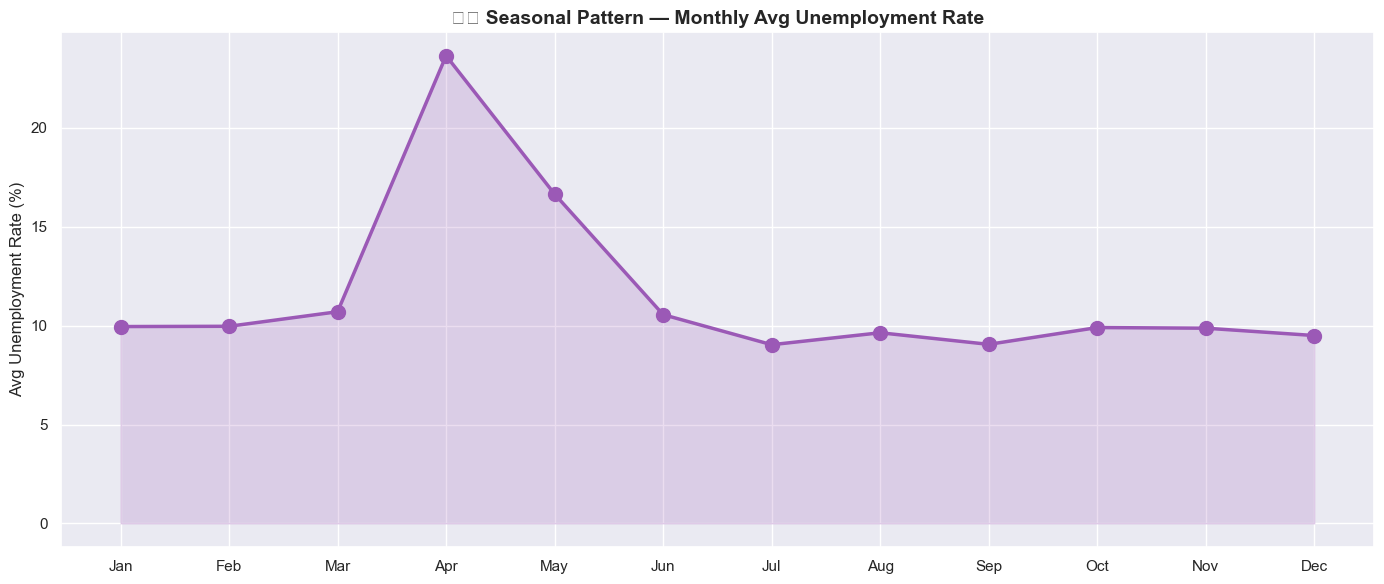

💡 Insight: April–June typically higher due to academic year and seasonal job cycles


In [13]:
# ── Plot 5: Seasonal/Monthly Patterns ──
monthly_pattern = df.groupby('Month')['Unemployment_Rate'].mean().reset_index()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_pattern['Month'], monthly_pattern['Unemployment_Rate'],
        marker='o', linewidth=2.5, color='#9B59B6', markersize=10)
ax.fill_between(monthly_pattern['Month'], monthly_pattern['Unemployment_Rate'], alpha=0.2, color='#9B59B6')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_title('🗓️ Seasonal Pattern — Monthly Avg Unemployment Rate', fontsize=14, fontweight='bold')
ax.set_ylabel('Avg Unemployment Rate (%)')
plt.tight_layout()
plt.savefig('plot_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Insight: April–June typically higher due to academic year and seasonal job cycles")

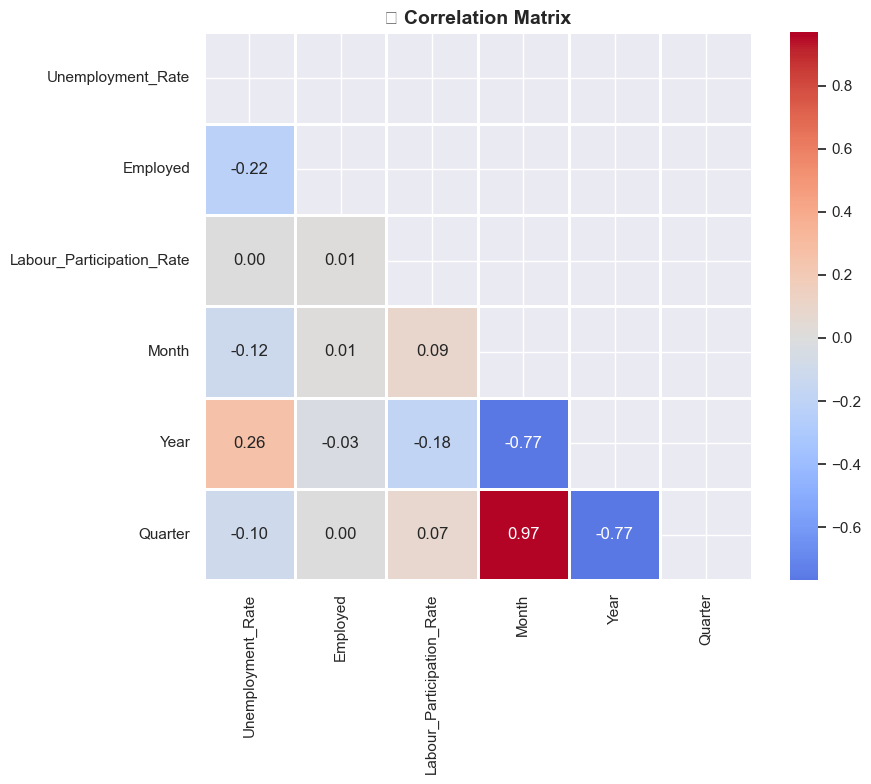

💡 Correlation tells us which features influence unemployment rate


In [14]:
# ── Plot 6: Correlation Heatmap ──
numeric_cols = df[['Unemployment_Rate', 'Employed', 'Labour_Participation_Rate', 'Month', 'Year', 'Quarter']]
corr = numeric_cols.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, ax=ax, square=True, linewidths=1)
ax.set_title('🔗 Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Correlation tells us which features influence unemployment rate")

## 5️⃣ Feature Engineering & Model Building

In [15]:
# Label Encode the 'State' column (text → numbers)
le = LabelEncoder()
df['State_Encoded'] = le.fit_transform(df['State'])

# Save the label encoder too (we need it for predictions)
joblib.dump(le, 'label_encoder.pkl')
print("✅ Label encoder saved")

# Define features and target
feature_cols = ['State_Encoded', 'Month', 'Year', 'Quarter', 'Labour_Participation_Rate']
X = df[feature_cols]
y = df['Unemployment_Rate']

print(f"\n🎯 Target: Unemployment_Rate")
print(f"📥 Features: {feature_cols}")
print(f"\n📦 Dataset size: {X.shape}")

✅ Label encoder saved

🎯 Target: Unemployment_Rate
📥 Features: ['State_Encoded', 'Month', 'Year', 'Quarter', 'Labour_Participation_Rate']

📦 Dataset size: (740, 5)


In [16]:
# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"🏋️ Training samples: {len(X_train)}")
print(f"🧪 Testing samples: {len(X_test)}")

🏋️ Training samples: 592
🧪 Testing samples: 148


In [17]:
# Train Random Forest Model
rf_model = RandomForestRegressor(
    n_estimators=200,       # 200 decision trees
    max_depth=10,           # each tree can go 10 levels deep
    min_samples_split=5,
    random_state=42,
    n_jobs=-1               # use all CPU cores
)

rf_model.fit(X_train, y_train)
print("✅ Random Forest trained!")

# Predictions
y_pred = rf_model.predict(X_test)

# Evaluation metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"\n📊 Model Performance:")
print(f"   R² Score  : {r2:.4f}  (1.0 = perfect, >0.85 = great)")
print(f"   RMSE      : {rmse:.4f}  (lower = better)")
print(f"   MAE       : {mae:.4f}  (avg prediction error in %)")

✅ Random Forest trained!

📊 Model Performance:
   R² Score  : 0.5323  (1.0 = perfect, >0.85 = great)
   RMSE      : 8.2285  (lower = better)
   MAE       : 4.7560  (avg prediction error in %)


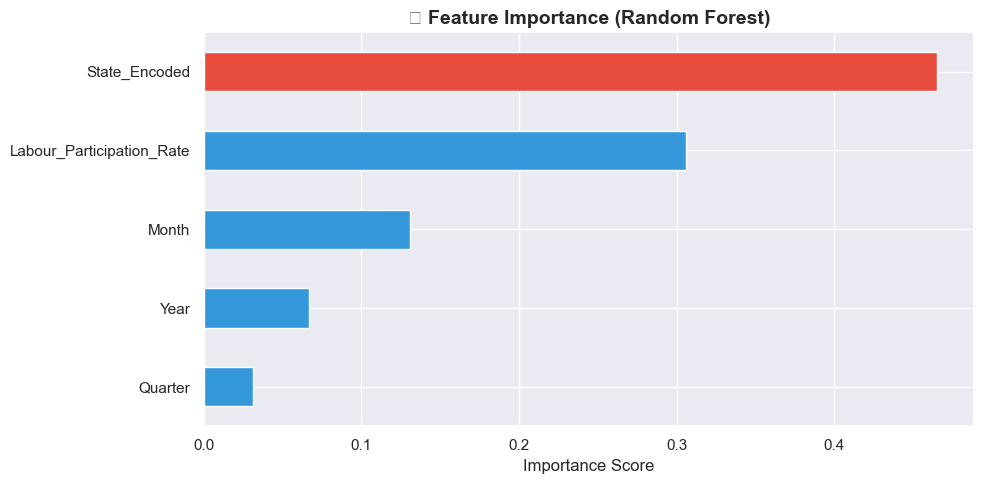

In [18]:
# Feature Importance — which features matter most?
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#3498DB' if v < importances.max() else '#E74C3C' for v in importances]
importances.plot(kind='barh', ax=ax, color=colors)
ax.set_title('🔍 Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

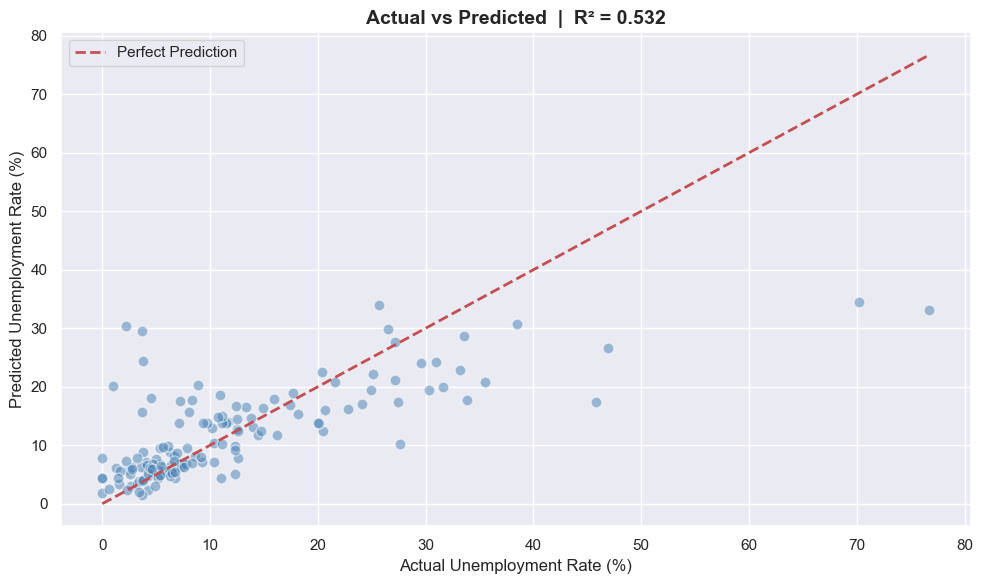

In [19]:
# Actual vs Predicted plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='white', s=60)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Unemployment Rate (%)')
ax.set_ylabel('Predicted Unemployment Rate (%)')
ax.set_title(f'Actual vs Predicted  |  R² = {r2:.3f}', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Compare Multiple Models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': rf_model,
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results.append({
        'Model': name,
        'R²': round(r2_score(y_test, preds), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, preds)), 4),
        'MAE': round(mean_absolute_error(y_test, preds), 4)
    })

results_df = pd.DataFrame(results)
print("📊 Model Comparison:")
print(results_df.to_string(index=False))

📊 Model Comparison:
            Model     R²    RMSE    MAE
Linear Regression 0.1297 11.2250 7.6226
    Random Forest 0.5323  8.2285 4.7560
Gradient Boosting 0.4282  9.0984 5.2187


In [21]:
# Save the best model (Random Forest) as pkl
joblib.dump(rf_model, 'unemployment_model.pkl')

# Save feature column order (important for correct predictions)
joblib.dump(feature_cols, 'feature_cols.pkl')

# Save state list for the frontend
state_list = sorted(df['State'].unique().tolist())
joblib.dump(state_list, 'states_list.pkl')

print("✅ Model saved: unemployment_model.pkl")
print("✅ Label encoder saved: label_encoder.pkl")
print("✅ Feature cols saved: feature_cols.pkl")
print("✅ States list saved: states_list.pkl")
print(f"\n🏆 Best Model: Random Forest with R² = {r2:.4f}")

✅ Model saved: unemployment_model.pkl
✅ Label encoder saved: label_encoder.pkl
✅ Feature cols saved: feature_cols.pkl
✅ States list saved: states_list.pkl

🏆 Best Model: Random Forest with R² = 0.5323
